# ApexPlanet Data Analytics Internship

## Task 3: Deep-Dive Analysis & Interactive Dashboarding

### Deep-Dive Topic
Customer Segmentation & Sales Performance Analysis

### Objective

The objective of this project is to perform an in-depth analysis of
customer purchasing behavior, define important business KPIs, segment
customers based on their value and purchasing patterns, and develop
an interactive business intelligence dashboard.

In [1]:
# import libreries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

In [2]:
# Load Task 1 Cleaned_Dataset.csv

df = pd.read_csv("../dataset/Cleaned_Dataset.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Year,Month,Day,Revenue_Per_Item,Age_Group
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,February,25,2829.77,26-40
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,October,14,27906.16,60+
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,May,13,37491.06,60+
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,December,2,28541.36,60+
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025,November,20,14036.59,41-60


In [3]:
df.shape

(1000, 17)

In [4]:
df.info

<bound method DataFrame.info of       Order_ID  Order_Date Customer_ID Customer_Name   Age  Gender       City  \
0    ORD100002  2025-02-25    CUST5529  Customer_227  30.0  Female  Bengaluru   
1    ORD100003  2025-10-14    CUST3127  Customer_182  63.0    Male  Bengaluru   
2    ORD100004  2025-05-13    CUST8887  Customer_487  62.0  Female  Bengaluru   
3    ORD100005  2025-12-02    CUST2515  Customer_470  65.0  Female    Kolkata   
4    ORD100006  2025-11-20    CUST4796  Customer_380  44.0    Male  Bengaluru   
..         ...         ...         ...           ...   ...     ...        ...   
995  ORD100997  2025-11-07    CUST6410  Customer_301  61.0    Male       Gaya   
996  ORD100998  2025-09-03    CUST7618  Customer_154  25.0    Male       Gaya   
997  ORD100999  2025-09-30    CUST9544  Customer_140  62.0  Female  Hyderabad   
998  ORD101000  2025-02-21    CUST9501  Customer_241   NaN    Male      Delhi   
999  ORD101001  2025-04-23    CUST2714   Customer_98  58.0  Female       Gaya

### KPI 1: Total Revenue

**Formula:** Sum of Total_Sales

Total Revenue measures the overall sales value generated by the
business and provides a high-level indication of business performance.

In [5]:
total_revenue = df["Total_Sales"].sum()

print("Total Revenue:", round(total_revenue, 2))

Total Revenue: 139399439.65


### KPI 2: Total Orders

**Formula:** Count of Unique Order IDs

Total Orders measures transaction volume and helps understand overall
customer purchasing activity.

In [6]:
total_orders = df["Order_ID"].nunique()

print("Total Orders:", total_orders)

Total Orders: 992


In [7]:
average_order_value = total_revenue / total_orders

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 140523.63


In [8]:
unique_customers = df["Customer_ID"].nunique()

print("Unique Customers:", unique_customers)

Unique Customers: 947


In [9]:
revenue_per_customer = total_revenue / unique_customers

print(
    "Average Revenue per Customer:",
    round(revenue_per_customer, 2)
)

Average Revenue per Customer: 147201.1


In [10]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Average Order Value",
        "Unique Customers",
        "Average Revenue per Customer"
    ],
    "Value": [
        total_revenue,
        total_orders,
        average_order_value,
        unique_customers,
        revenue_per_customer
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,1.393994e+08
1,Total Orders,9.920000e+02
2,Average Order Value,1.405236e+05
3,Unique Customers,9.470000e+02
4,Average Revenue per Customer,1.472011e+05


In [11]:
customer_analysis = df.groupby(
    ["Customer_ID", "Customer_Name"]
).agg(
    Total_Revenue=("Total_Sales", "sum"),
    Total_Orders=("Order_ID", "nunique"),
    Total_Quantity=("Quantity", "sum"),
    Average_Order_Value=("Total_Sales", "mean")
).reset_index()

customer_analysis.head()

,Customer_ID,Customer_Name,Total_Revenue,Total_Orders,Total_Quantity,Average_Order_Value
0,CUST1004,Customer_191,8321.54,1,2,8321.54
1,CUST1017,Customer_387,264230.68,1,7,264230.68
2,CUST1026,Customer_445,164965.29,1,7,164965.29
3,CUST1032,Customer_20,146990.90,1,7,146990.90
4,CUST1038,Customer_454,37068.40,1,5,37068.40


In [ ]:
customer_analysis.describe()

In [12]:
q1 = customer_analysis["Total_Revenue"].quantile(0.25)
q2 = customer_analysis["Total_Revenue"].quantile(0.50)
q3 = customer_analysis["Total_Revenue"].quantile(0.75)

print("25th Percentile:", q1)
print("Median:", q2)
print("75th Percentile:", q3)

25th Percentile: 47066.6325
Median: 108594.025
75th Percentile: 203722.8825


In [13]:
def customer_segment(revenue):

    if revenue >= q3:
        return "High Value"

    elif revenue >= q2:
        return "Medium Value"

    else:
        return "Low Value"


customer_analysis["Customer_Segment"] = (
    customer_analysis["Total_Revenue"]
    .apply(customer_segment)
)

customer_analysis.head()

,Customer_ID,Customer_Name,Total_Revenue,Total_Orders,Total_Quantity,Average_Order_Value,Customer_Segment
0,CUST1004,Customer_191,8321.54,1,2,8321.54,Low Value
1,CUST1017,Customer_387,264230.68,1,7,264230.68,High Value
2,CUST1026,Customer_445,164965.29,1,7,164965.29,Medium Value
3,CUST1032,Customer_20,146990.90,1,7,146990.90,Medium Value
4,CUST1038,Customer_454,37068.40,1,5,37068.40,Low Value


In [14]:
customer_analysis["Customer_Segment"].value_counts()

Customer_Segment
Low Value       500
High Value      250
Medium Value    250
Name: count, dtype: int64

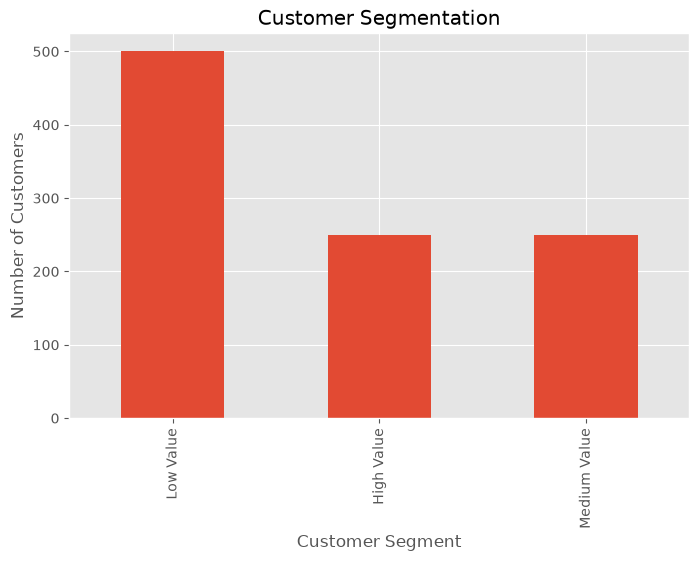

In [15]:
customer_analysis[
    "Customer_Segment"
].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

In [16]:
segment_revenue = customer_analysis.groupby(
    "Customer_Segment"
)["Total_Revenue"].sum().sort_values(
    ascending=False
)

segment_revenue

Customer_Segment
High Value      76211441.11
Medium Value    37901133.57
Low Value       25286864.97
Name: Total_Revenue, dtype: float64

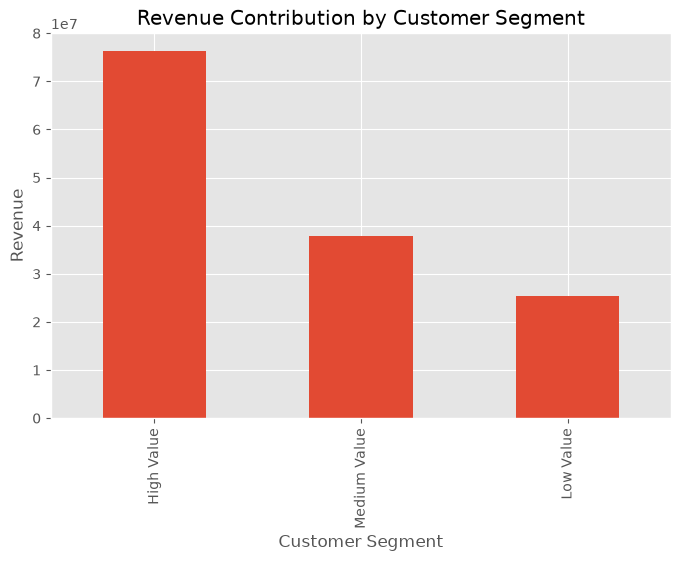

In [17]:
segment_revenue.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

plt.show()

In [18]:
top_customers = customer_analysis.sort_values(
    "Total_Revenue",
    ascending=False
).head(10)

top_customers

,Customer_ID,Customer_Name,Total_Revenue,Total_Orders,Total_Quantity,Average_Order_Value,Customer_Segment
112,CUST2062,Customer_254,493677.5,1,10,493677.5,High Value
400,CUST4706,Customer_200,492174.1,1,10,492174.1,High Value
70,CUST1711,Customer_36,490866.4,1,10,490866.4,High Value
419,CUST4869,Customer_392,485667.8,1,10,485667.8,High Value
699,CUST7416,Customer_191,482551.9,1,10,482551.9,High Value
944,CUST9551,Customer_230,474935.9,1,10,474935.9,High Value
798,CUST8381,Customer_112,473144.2,1,10,473144.2,High Value
336,CUST4037,Customer_205,470798.6,1,10,470798.6,High Value
333,CUST4003,Customer_305,468522.0,1,10,468522.0,High Value
385,CUST4584,Customer_138,462701.3,1,10,462701.3,High Value


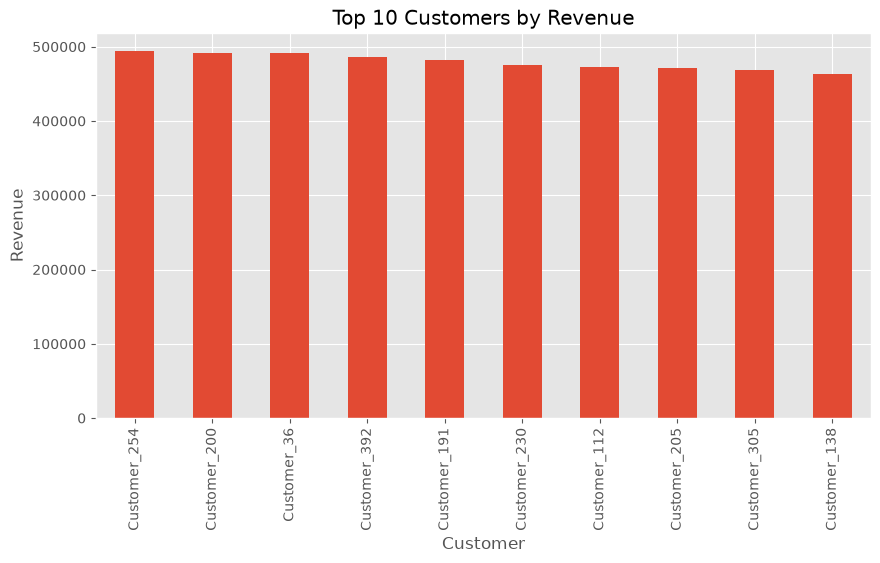

In [19]:
top_customers.plot(
    x="Customer_Name",
    y="Total_Revenue",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer")
plt.ylabel("Revenue")

plt.show()

In [20]:
category_analysis = df.groupby(
    "Category"
).agg(
    Revenue=("Total_Sales", "sum"),
    Quantity=("Quantity", "sum"),
    Orders=("Order_ID", "nunique")
).reset_index()

category_analysis.sort_values(
    "Revenue",
    ascending=False
)

,Category,Revenue,Quantity,Orders
1,Electronics,50778581.70,1978,353
0,Education,25031689.40,977,177
4,Grocery,22231711.28,826,151
3,Furniture,21521561.48,855,158
2,Fashion,19835895.79,799,156


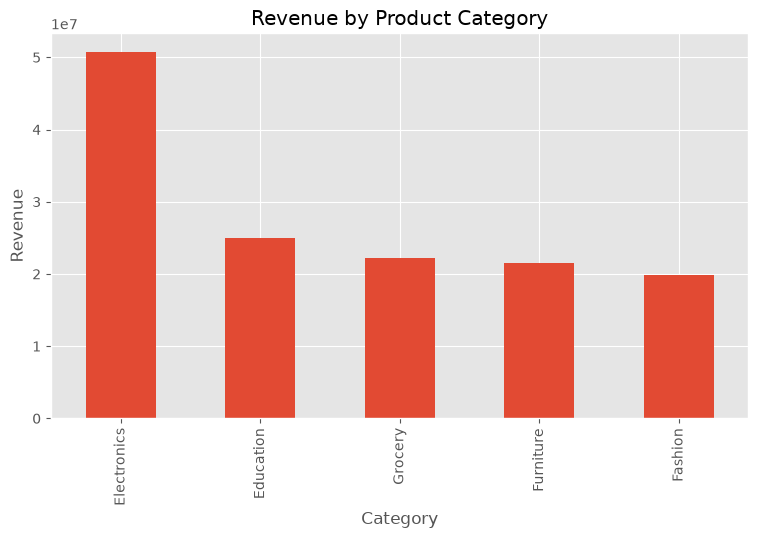

In [21]:
category_analysis.sort_values(
    "Revenue",
    ascending=False
).plot(
    x="Category",
    y="Revenue",
    kind="bar",
    figsize=(9,5),
    legend=False
)

plt.title("Revenue by Product Category")
plt.ylabel("Revenue")

plt.show()

In [22]:
product_analysis = df.groupby(
    "Product"
).agg(
    Revenue=("Total_Sales", "sum"),
    Quantity=("Quantity", "sum"),
    Orders=("Order_ID", "nunique")
).reset_index()

product_analysis = product_analysis.sort_values(
    "Revenue",
    ascending=False
)

product_analysis.head(10)

,Product,Revenue,Quantity,Orders
2,Laptop,25443008.51,970,170
3,Mobile,25335573.19,1008,184
0,Book,25031689.40,977,177
4,Rice,22231711.28,826,151
1,Chair,21521561.48,855,158
5,Shoes,19835895.79,799,156


In [23]:
city_analysis = df.groupby(
    "City"
).agg(
    Revenue=("Total_Sales", "sum"),
    Orders=("Order_ID", "nunique"),
    Customers=("Customer_ID", "nunique")
).reset_index()

city_analysis.sort_values(
    "Revenue",
    ascending=False
).head(10)

,City,Revenue,Orders,Customers
6,Patna,19285966.89,135,134
4,Kolkata,18884349.57,132,132
0,Bengaluru,18773574.32,120,120
5,Mumbai,18757050.17,131,130
3,Hyderabad,17166766.87,125,125
1,Delhi,16097079.00,125,124
7,Pune,14513175.90,98,99
2,Gaya,14380859.39,117,117


In [24]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Year_Month"] = (
    df["Order_Date"]
    .dt.to_period("M")
    .astype(str)
)

In [25]:
monthly_analysis = df.groupby(
    "Year_Month"
)["Total_Sales"].sum()

monthly_analysis

Year_Month
2025-01    10096190.73
2025-02    11511181.46
2025-03    13059899.94
2025-04    12222700.17
2025-05    10984689.25
2025-06    12912332.64
2025-07    11746226.80
2025-08     9448471.22
2025-09     9179896.29
2025-10    12500936.50
2025-11    12627620.22
2025-12    12299904.44
2026-01      809389.99
Name: Total_Sales, dtype: float64

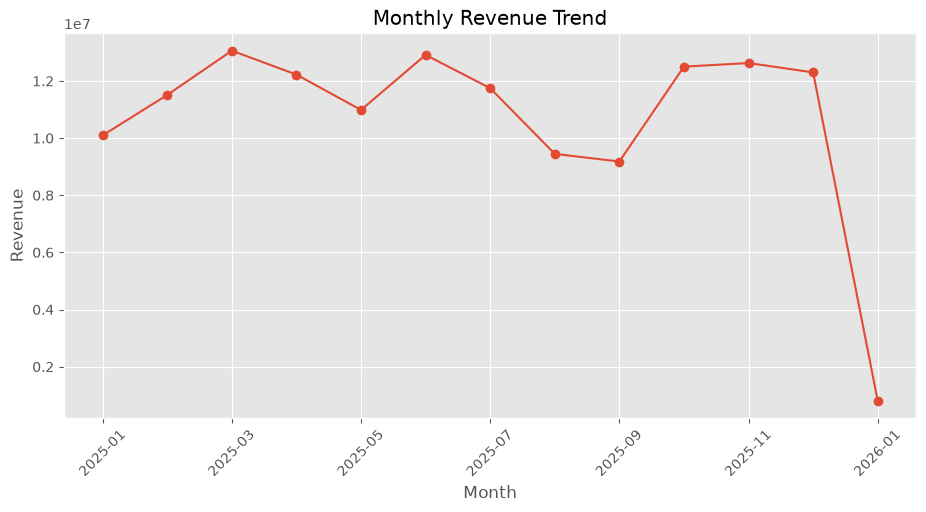

In [26]:
monthly_analysis.plot(
    kind="line",
    marker="o",
    figsize=(11,5)
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

In [27]:
dashboard_data = df.merge(
    customer_analysis[
        ["Customer_ID", "Customer_Segment"]
    ],
    on="Customer_ID",
    how="left"
)

dashboard_data.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Year,Month,Day,Revenue_Per_Item,Age_Group,Year_Month,Customer_Segment
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,February,25,2829.77,26-40,2025-02,Low Value
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,October,14,27906.16,60+,2025-10,Medium Value
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,May,13,37491.06,60+,2025-05,High Value
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,December,2,28541.36,60+,2025-12,Medium Value
4,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,December,2,28541.36,60+,2025-12,High Value


In [ ]:
dashboard_data.to_csv(
    "Task3_Dashboard_Data.csv",
    index=False
)

print("Dashboard dataset exported successfully.")

Dashboard dataset exported successfully.
